# Notebook 05: What is shear-wave splitting?

**Goal (about 2 hours, can be split over two sessions):** build the splitting measurement yourself on a synthetic signal where the answer is known. By the end you will have written a tiny version of what SWSPy does, and you will know exactly what "phi" and "dt" mean.

No library does the splitting here: just numpy. The physics reference is Crampin & Peacock (2008), *Wave Motion* 45, 675-722; the method is Silver & Chan (1991), *JGR* 96, 16429-16454.

In [1]:
# --- setup: make the repo importable and keep figures inline ---
import sys, warnings
from pathlib import Path
REPO = Path.cwd().parent if (Path.cwd() / "../rainier_sws").exists() else Path.cwd()
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
from rainier_sws import paths, data, measure, quality, stats
print("repo:", REPO)

repo: /home/claude/rainier-sws-tutorials


## 1. The physical picture

Shallow rock is full of small cracks, and cracks tend to line up with the direction of maximum compressive stress (they close perpendicular to it). An S wave shaking the ground *parallel* to the cracks does not care about them and travels at the normal speed. An S wave shaking *across* the cracks has to compress the crack fluid and travels slightly slower.

A general S wave is a vector; decompose it into those two polarizations and the two parts travel at different speeds. By the time they reach the station the slow one lags the fast one by **dt**. The orientation of the fast one is **phi** (degrees clockwise from north; it is an axis so phi and phi + 180 are the same).

For an ECE student: the ground between earthquake and station is a two-input two-output linear system whose eigenmodes are "shake along phi" and "shake across phi", with impulse responses delta(t) and delta(t - dt). We want to identify phi and dt from the output alone.

## 2. Make a split wave

Start with a clean S pulse polarized in some direction (the *source polarization*), then apply the split: rotate into the fast/slow frame, delay the slow component, rotate back to north/east.

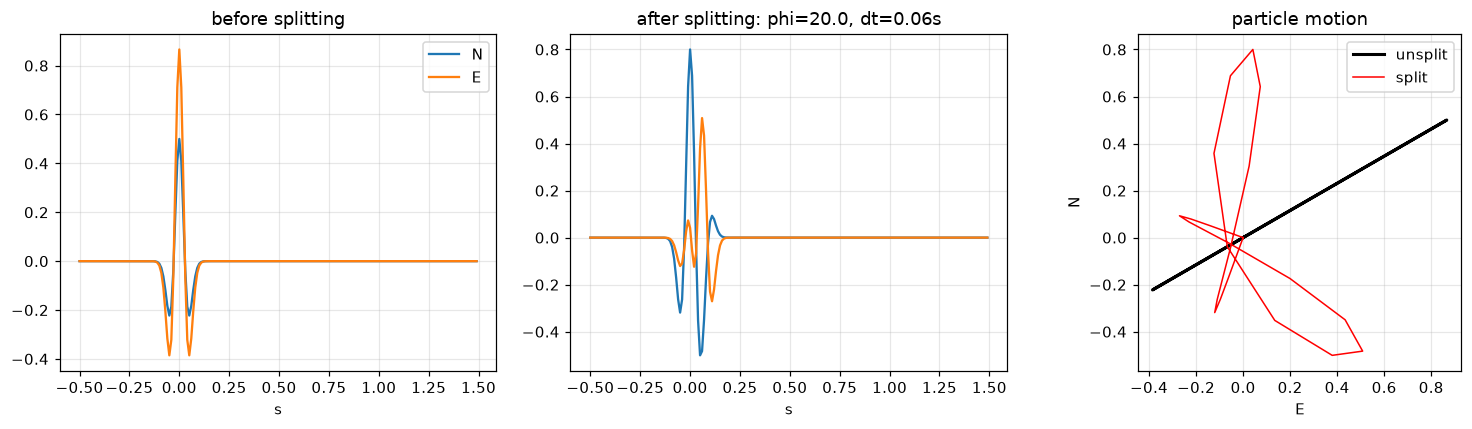

In [2]:
fs = 100.0
t = np.arange(-0.5, 1.5, 1 / fs)

def ricker(t, f0=8.0):
    a = (np.pi * f0 * t) ** 2
    return (1 - 2 * a) * np.exp(-a)

def rot(x, y, deg):
    """rotate the (x=east, y=north) pair counter-clockwise by deg... careful: we rotate the coordinate FRAME."""
    th = np.deg2rad(deg)
    return x * np.cos(th) - y * np.sin(th), x * np.sin(th) + y * np.cos(th)

def split(n, e, phi, dt, fs=fs):
    """Apply splitting with fast axis phi (deg clockwise from N) and delay dt (s) to north/east traces."""
    # fast/slow frame: fast = component along phi, slow = perpendicular
    th = np.deg2rad(phi)
    fast = n * np.cos(th) + e * np.sin(th)
    slow = -n * np.sin(th) + e * np.cos(th)
    slow = np.roll(slow, int(round(dt * fs)))          # delay the slow wave
    n2 = fast * np.cos(th) - slow * np.sin(th)
    e2 = fast * np.sin(th) + slow * np.cos(th)
    return n2, e2

src_pol, PHI_TRUE, DT_TRUE = 60.0, 20.0, 0.06
pulse = ricker(t)
n0, e0 = pulse * np.cos(np.deg2rad(src_pol)), pulse * np.sin(np.deg2rad(src_pol))   # unsplit
n1, e1 = split(n0, e0, PHI_TRUE, DT_TRUE)                                             # split

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(t, n0, label="N"); axes[0].plot(t, e0, label="E"); axes[0].set_title("before splitting"); axes[0].legend()
axes[1].plot(t, n1, label="N"); axes[1].plot(t, e1, label="E"); axes[1].set_title(f"after splitting: phi={PHI_TRUE}, dt={DT_TRUE}s")
axes[2].plot(e0, n0, "k", lw=2, label="unsplit"); axes[2].plot(e1, n1, "r", lw=1, label="split")
axes[2].set_aspect("equal"); axes[2].set_xlabel("E"); axes[2].set_ylabel("N"); axes[2].set_title("particle motion"); axes[2].legend()
for ax in axes[:2]: ax.set_xlabel("s")
plt.tight_layout()

The right panel is the key diagnostic in all of shear-wave splitting. An unsplit S wave has **linear** particle motion (the ground moves back and forth along one line). After splitting, the two delayed components combine into an **ellipse**. The whole measurement is: find the (phi, dt) that turns the ellipse back into a line.

## 3. Undo the split: the grid search

For a trial (phi, dt): rotate into the trial fast/slow frame, advance the slow component by dt, and ask how linear the motion now is. Linearity is measured by the eigenvalues of the 2x2 covariance matrix of the two components: a line has one large eigenvalue and one that is (almost) zero. So we minimize the smaller eigenvalue lambda2 over a grid (Silver & Chan's "eigenvalue method"). SWSPy also uses the cross-correlation between the two components; we keep it simple.

In [3]:
def unsplit(n, e, phi, dt, fs=fs):
    th = np.deg2rad(phi)
    fast = n * np.cos(th) + e * np.sin(th)
    slow = -n * np.sin(th) + e * np.cos(th)
    slow = np.roll(slow, -int(round(dt * fs)))
    return fast, slow

def lambda2(n, e, phi, dt, win):
    f, s = unsplit(n, e, phi, dt)
    cov = np.cov(np.vstack([f[win], s[win]]))
    return np.linalg.eigvalsh(cov)[0]          # smaller eigenvalue

phis = np.arange(0, 180, 1.0)
dts = np.arange(0, 0.2, 0.01)
win = (t > -0.2) & (t < 0.6)                   # analysis window around the pulse
grid = np.array([[lambda2(n1, e1, p, d, win) for d in dts] for p in phis])
ip, idt = np.unravel_index(np.argmin(grid), grid.shape)
print(f"recovered phi = {phis[ip]:.0f} deg, dt = {dts[idt]:.2f} s   (truth: {PHI_TRUE}, {DT_TRUE})")

recovered phi = 20 deg, dt = 0.06 s   (truth: 20.0, 0.06)


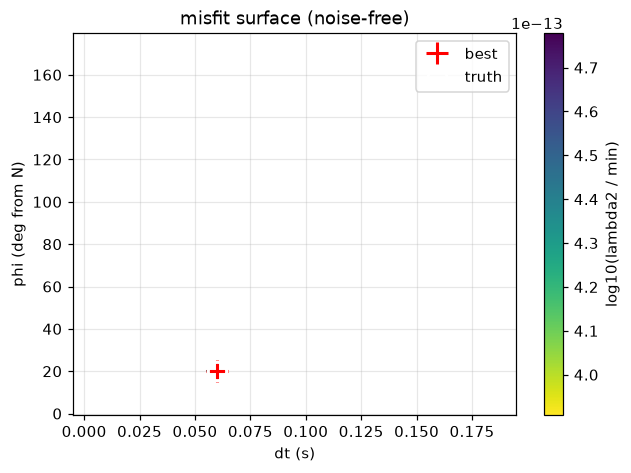

In [4]:
def show_grid(grid, phis, dts, title, truth=None):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    im = ax.pcolormesh(dts, phis, np.log10(grid / grid.min() + 1e-12), shading="nearest", cmap="viridis_r")
    ax.set_xlabel("dt (s)"); ax.set_ylabel("phi (deg from N)"); ax.set_title(title)
    plt.colorbar(im, label="log10(lambda2 / min)")
    ip, idt = np.unravel_index(np.argmin(grid), grid.shape)
    ax.plot(dts[idt], phis[ip], "r+", ms=14, mew=2, label="best")
    if truth: ax.plot(truth[1], truth[0], "wo", mfc="none", ms=12, mew=2, label="truth")
    ax.legend(loc="upper right")
show_grid(grid, phis, dts, "misfit surface (noise-free)", (PHI_TRUE, DT_TRUE))

Note the shape of the surface: a sharp minimum at the truth, but also a faint second valley at phi + 90 (fast and slow swapped, with negative dt, which the grid does not contain) and ridges one period apart in dt. Those are the **cycle-skip** and **null** ambiguities of notebook 08.

## 4. Now add noise, and the error bars appear

Real seismograms are noisy. Add Gaussian noise at a chosen SNR and look at the misfit surface again. The minimum gets broader: the set of (phi, dt) that fit "almost as well" is the uncertainty. Silver & Chan turn this into a formal error with an F-test on the misfit; the broad idea is simply: *the width of the valley is the error bar.*

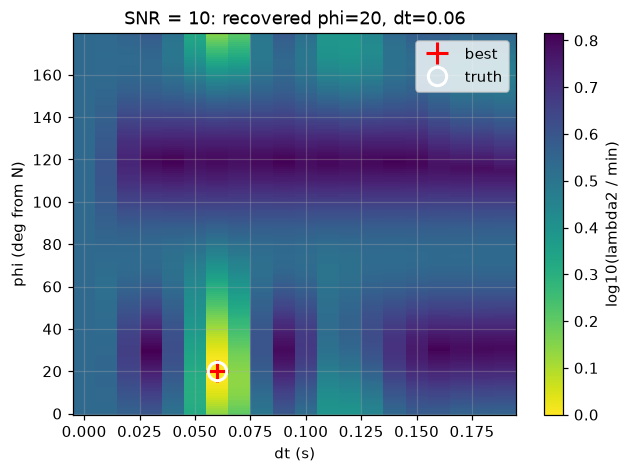

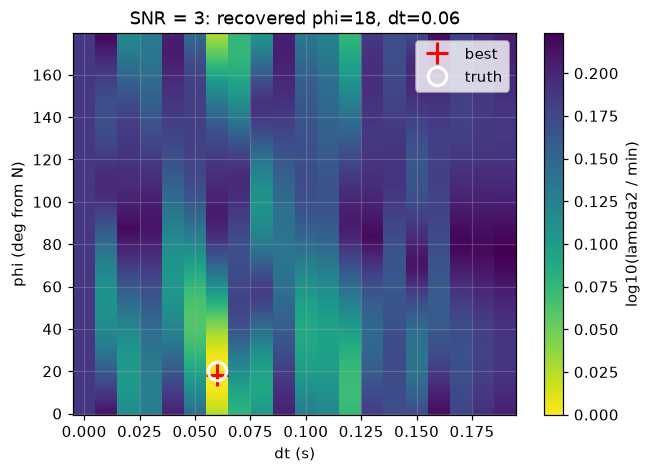

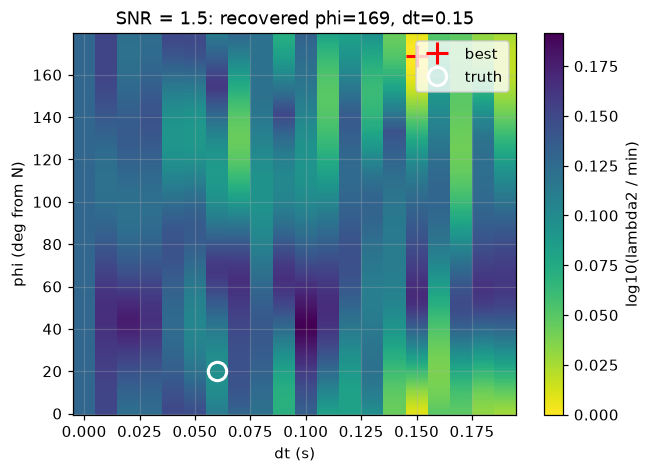

In [5]:
rng = np.random.default_rng(1)
def add_noise(n, e, snr):
    amp = np.max(np.abs(np.hypot(n, e))) / snr
    return n + rng.normal(0, amp, n.size), e + rng.normal(0, amp, e.size)

for snr in (10, 3, 1.5):
    nn, ee = add_noise(n1, e1, snr)
    g = np.array([[lambda2(nn, ee, p, d, win) for d in dts] for p in phis])
    ip, idt = np.unravel_index(np.argmin(g), g.shape)
    show_grid(g, phis, dts, f"SNR = {snr}: recovered phi={phis[ip]:.0f}, dt={dts[idt]:.2f}", (PHI_TRUE, DT_TRUE))

## 5. A first calibration experiment

Repeat the noisy recovery many times at each SNR and look at the spread of recovered phi and dt. This is the simplest possible answer to "how good is the measurement as a function of SNR?", and it is the template for the real calibration in notebook 08.

In [6]:
def recover(n, e):
    g = np.array([[lambda2(n, e, p, d, win) for d in dts] for p in phis])
    ip, idt = np.unravel_index(np.argmin(g), g.shape)
    return phis[ip], dts[idt]

snrs = [1.5, 2, 3, 5, 10, 20]
rows = []
for snr in snrs:
    for k in range(25):
        p, d = recover(*add_noise(n1, e1, snr))
        rows.append({"snr": snr, "phi": p, "dt": d})
res = pd.DataFrame(rows)
res["phi_err"] = stats.axial_diff(res.phi, PHI_TRUE)
res["dt_err"] = (res.dt - DT_TRUE).abs()
summary = res.groupby("snr").agg(phi_err_median=("phi_err", "median"), phi_err_p90=("phi_err", lambda x: np.percentile(x, 90)),
                                 dt_err_median=("dt_err", "median"), dt_err_p90=("dt_err", lambda x: np.percentile(x, 90)))
summary

,phi_err_median,phi_err_p90,dt_err_median,dt_err_p90
snr,,,,
1.5,39.0,66.4,0.05,0.106
2.0,35.0,49.6,0.03,0.100
3.0,26.0,51.4,0.01,0.126
5.0,9.0,29.6,0.00,0.050
10.0,3.0,8.2,0.00,0.000
20.0,2.0,4.0,0.00,0.000


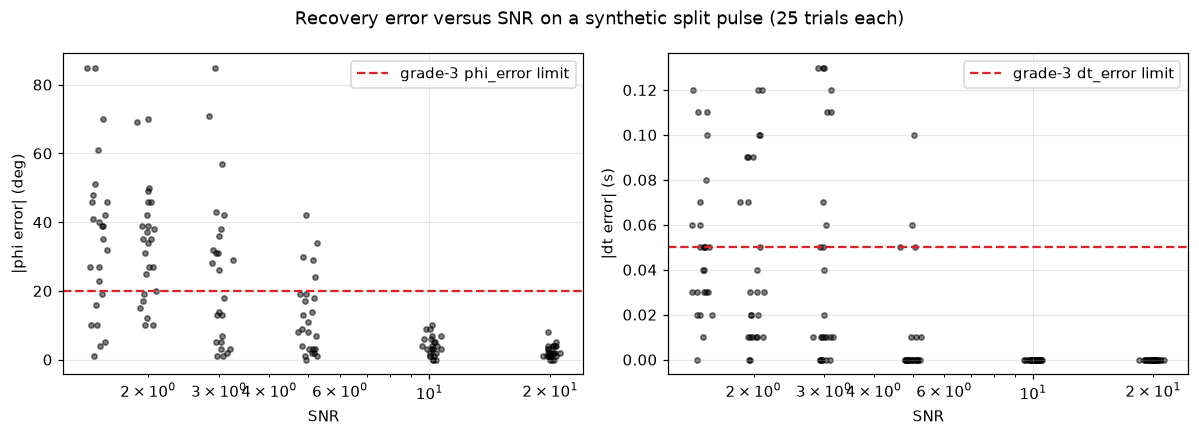

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, lab in zip(axes, ["phi_err", "dt_err"], ["|phi error| (deg)", "|dt error| (s)"]):
    ax.scatter(res.snr + rng.normal(0, 0.03, len(res)) * res.snr, res[col], s=12, alpha=0.5, c="k")
    ax.set_xscale("log"); ax.set_xlabel("SNR"); ax.set_ylabel(lab)
axes[0].axhline(20, color="tab:red", ls="--", label="grade-3 phi_error limit"); axes[0].legend()
axes[1].axhline(0.05, color="tab:red", ls="--", label="grade-3 dt_error limit"); axes[1].legend()
fig.suptitle("Recovery error versus SNR on a synthetic split pulse (25 trials each)")
plt.tight_layout()

Below SNR about 2 the measurement falls apart; above about 5 it is excellent. The research pipeline's SNR gate of 2.0 sits right at the edge; whether that is a good choice for *real* data (where noise is not white and the source pulse is not a clean Ricker) is a question you will test with real seismograms in notebook 08.

## 6. The null measurement

What if the source polarization happens to be *along* the fast axis (or exactly across it)? Then there is no slow component to delay, the wave arrives unsplit, and the misfit surface has no meaningful minimum: phi is undetermined and dt can be anything. These "nulls" are not failures of the method, they are real and informative, but a naive grid search still returns a number for them.

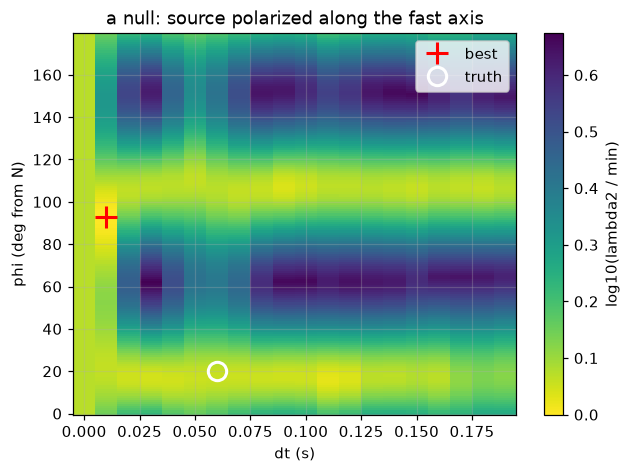

In [8]:
n_null, e_null = pulse * np.cos(np.deg2rad(PHI_TRUE)), pulse * np.sin(np.deg2rad(PHI_TRUE))  # source pol == phi
nn, ee = add_noise(*split(n_null, e_null, PHI_TRUE, DT_TRUE), 10)
g = np.array([[lambda2(nn, ee, p, d, win) for d in dts] for p in phis])
show_grid(g, phis, dts, "a null: source polarized along the fast axis", (PHI_TRUE, DT_TRUE))

The surface is a trough along a whole line rather than a point: dt is unconstrained (any dt gives the same misfit) and phi is only known to be either the source polarization or 90 degrees from it. In real data, nulls show up as phi near the back azimuth or perpendicular to it with a large dt error. Notebook 08 screens for them.

## 7. Exercises

1. Change the source polarization to 30 degrees from the fast axis. Is the ellipse fatter or thinner? Does the recovery at SNR 2 get better or worse?
2. Make the pulse higher frequency (`f0 = 15`) with the same dt. What happens to the misfit surface along the dt axis? (This is cycle skipping.)
3. Reduce the window `win` to just the first half of the pulse. Does the minimum move? Window choice is another knob the real pipeline sweeps over (`n_win = 7`).
4. Write `recover` as a function that also returns the *width* of the valley (for example the range of phi for which lambda2 is within 10 percent of its minimum). Plot that width against the actual error. Are they related? That relationship is what a formal error bar tries to capture.

Next: `05b_timing_and_clock_errors.ipynb` (same week): before trusting a window placed from a pick, check the clock. Then `06_single_event_with_swspy.ipynb`, the real thing.